# Ex. Single ERT File Inversion (No Time-Lapse)

This notebook shows a simple one-file ERT workflow using `ert_data_agent` functions directly:
1. Set a folder path or file path (default uses DAS example data).
2. (Optional) enable external `electrodes.dat` usage via `use_electrode_file`.
3. Process data (`load_ert_resipy`, `qc_and_visualize`, `export_for_inversion`).
4. Run one `ERTInversion`.
5. Save model outputs.


In [29]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path.cwd()

if (current_dir / "data" / "ERT").exists():
    examples_dir = current_dir
elif (current_dir / "examples" / "data" / "ERT").exists():
    examples_dir = current_dir / "examples"
else:
    examples_dir = current_dir

repo_root = examples_dir.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from PyHydroGeophysX.data_processing.ert_data_agent import (
    LocalRef,
    export_for_inversion,
    load_ert_resipy,
    qc_and_visualize,
)
from PyHydroGeophysX.inversion.ert_inversion import ERTInversion

In [30]:
# Default dataset: examples/data/ERT/DAS
input_path = examples_dir / "data" / "ERT" / "DAS"
instrument = "DAS-1"

# Optional external electrode coordinate file
use_electrode_file = True
electrode_file = input_path / "electrodes.dat"  # used only if use_electrode_file=True

# Error mode: False=recompute reciprocal error, True=use source error
use_source_error = False

output_dir = examples_dir / "results" / "ert_single_inversion_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

# Pick first data file from the folder
candidates = sorted(list(input_path.glob("*.Data")) + list(input_path.glob("*.data")) + list(input_path.glob("*.dat")) + list(input_path.glob("*.ohm")))
if not candidates:
    raise FileNotFoundError(f"No ERT data file found in {input_path}")
data_file = candidates[0]

print(f"Input folder: {input_path}")
print(f"Using file: {data_file}")
print(f"use_electrode_file: {use_electrode_file}")
print(f"use_source_error: {use_source_error}")
print(f"Output dir: {output_dir}")


Input folder: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS
Using file: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS\20171105_1418.Data
use_electrode_file: True
use_source_error: False
Output dir: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook


In [31]:
electrode_file_arg = None
if use_electrode_file:
    if not Path(electrode_file).exists():
        raise FileNotFoundError(f"Electrode file not found: {electrode_file}")
    electrode_file_arg = str(electrode_file)
    print(f"Using electrode file: {electrode_file_arg}")

ert = load_ert_resipy(
    project_dir=str(input_path),
    data_file=str(data_file),
    instrument=instrument,
    electrode_file=electrode_file_arg,
    crs="local",
    local_ref=LocalRef(origin_x=0.0, origin_y=0.0, azimuth_deg=90.0),
)

artifacts = qc_and_visualize(ert, outdir=str(output_dir))
bert_path = export_for_inversion(
    ert,
    outdir=str(output_dir),
    fmt="pgimli",
    use_source_error=use_source_error,
)

print(f"Instrument used: {instrument}")
print(f"BERT export: {bert_path}")
print("QC artifacts:")
for k, v in artifacts.items():
    print(f"  {k}: {v}")


Using electrode file: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS\electrodes.dat
Working directory is: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS
Working directory is: C:\Users\hchen117\AppData\Local\Temp\resipy_md47q5do
filterData: 0 / 945 quadrupoles removed.
930/945 reciprocal measurements found.
0 measurements error > 20 %
   Loaded 945 raw resistance measurements from DAS-1
   Updated electrode positions from electrodes.dat
   After basic QC filters: 945 measurements
   Applied reciprocal error filter (< 5%): removed 15 measurements
   Total filtered with DAS quality thresholds: 15 measurements
   After all QC filters: 930 measurements


c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\data_processing\ert_data_agent.py:1369: UserWarning: RESIPY cannot prepare project directory 'c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS' (PermissionError). Falling back to a temporary project directory.
  warnings.warn(
20/02/26 - 16:44:18 - pyGIMLi - INFO - Create default mesh for geometric factor calculation.


   DEBUG: Writing 56 electrodes to file
   DEBUG: First electrode: x=21.375, y=2965.981, z=0.000
   DEBUG: Last electrode: x=103.875, y=2939.099, z=0.000
   DEBUG: Coordinate ranges: x=[21.375, 103.875], y=[2938.389, 2965.981], z=[0.000, 0.000]
   DEBUG: Inferred elevation axis: y
   DEBUG: app_res source metadata: resistance
   DEBUG: Error mode: reciprocal (auto-estimated)
   DEBUG: Reciprocal-error estimate on export rows: paired=930/930, err_range=[0.010, 0.024]
   DEBUG: Wrote 930 valid observations
   Exported data to c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\bert_data.dat
   Validating geometric factors... [CODE-VERSION: 2026-02-20-v4-safe-export]
   DEBUG: PyGIMLi loaded 56 electrode positions
   DEBUG: Loaded coordinate ranges: x=[21.375, 103.875], y=[2938.389, 2965.981], z=[0.000, 0.000]
   DEBUG: Inferred elevation axis (loaded): y
   Computing geometric factors with PyGIMLi...


20/02/26 - 16:44:20 - pyGIMLi - INFO - Save RVector binary
20/02/26 - 16:44:20 - pyGIMLi - INFO - Cache stored: C:\Users\hchen117\AppData\Roaming\pygimli\Cache\13800391801246994681


   Computed K range: [9.3, 155.4]
   Filtered 27 measurements with extreme apparent resistivity
   Final dataset: 903 measurements with computed K
   DEBUG: Reciprocal-error estimate on final rows: paired=902/903, err_range=[0.010, 0.050]
   DEBUG: Skipped 27 non-finite rows during final rewrite
   Saved data with computed K to c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\bert_data.dat
Instrument used: DAS-1
BERT export: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\bert_data.dat
QC artifacts:
  electrodes_png: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\electrodes.png
  rhoa_hist_png: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\rhoa_hist.png
  observations_p

In [32]:
inversion = ERTInversion(
    data_file=bert_path,
    lambda_val=10.0,
    method="cgls",
    max_iterations=10,
    lambda_rate=1.0,
    use_gpu=False,
)
result = inversion.run()

20/02/26 - 16:44:20 - pyGIMLi - INFO - Found 2 regions.
20/02/26 - 16:44:20 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/02/26 - 16:44:20 - pyGIMLi - INFO - Found 2 regions.
20/02/26 - 16:44:20 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/02/26 - 16:44:20 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/02/26 - 16:44:20 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


DEBUG [ert_inversion.py]: Data has 56 electrode positions before mesh creation
DEBUG [ert_inversion.py]: Electrode Y-range (elevation): [2938.389, 2965.981]
DEBUG [ert_inversion.py]: Mesh created with 949 nodes, 1735 cells
DEBUG [ert_inversion.py]: Mesh Y-range: [2576.099, 2965.981]
   Using provided error estimates (mean: 0.0102, range: [0.0100, 0.0500])


20/02/26 - 16:44:20 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3632 Cells: 6940 Boundaries: 5366


-------------------Iteration: 0 ---------------------------
chi2: 2349.703175609927
dPhi: 1.0
-------------------Iteration: 1 ---------------------------
chi2: 191.1072793020691
dPhi: 0.9186674805201887
-------------------Iteration: 2 ---------------------------
chi2: 47.74109562307531
dPhi: 0.7501869327142975
-------------------Iteration: 3 ---------------------------
chi2: 9.059515473476479
dPhi: 0.8102365403382651
-------------------Iteration: 4 ---------------------------
chi2: 0.4021013388598316
dPhi: 0.9556155801006067
End of inversion


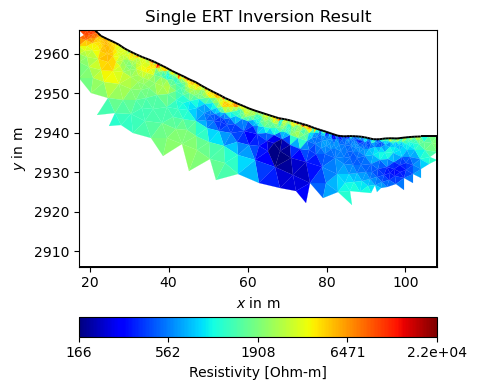

Saved model figure: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\single_ert_model_notebook.png


In [33]:
fig, ax = plt.subplots(figsize=(10, 4))


pg.show(
    result.mesh,
    result.final_model,
    ax=ax,
    cMap="jet",
    logScale=True,
    coverage=result.coverage>-1,
    label="Resistivity [Ohm-m]",
)
ax.set_title("Single ERT Inversion Result")
fig.tight_layout()

fig_path = output_dir / "single_ert_model_notebook.png"
fig.savefig(fig_path, dpi=200)
plt.show()

np.save(output_dir / "final_model.npy", result.final_model)
np.save(output_dir / "predicted_data.npy", result.predicted_data)
np.save(output_dir / "coverage.npy", result.coverage)
print(f"Saved model figure: {fig_path}")

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x1b221e4bc50>)

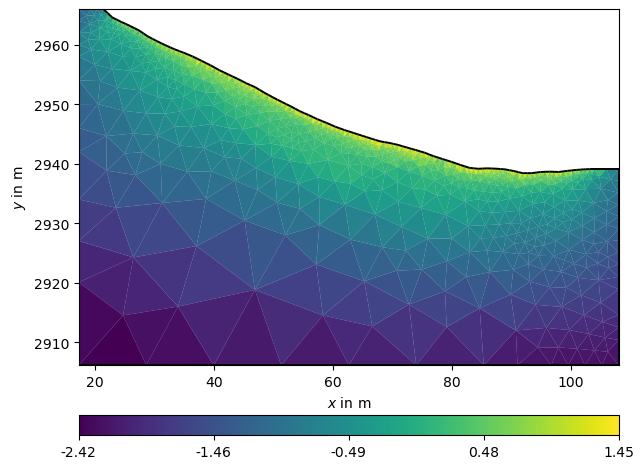

In [34]:
pg.show(result.mesh,result.coverage)

To run the script version from terminal:

```bash
python examples/Ex_ERT_single_inversion.py --input examples/data/ERT/DAS --instrument DAS-1
# Optional electrode file mode:
python examples/Ex_ERT_single_inversion.py --input examples/data/ERT/DAS --instrument DAS-1 --use-electrode-file --electrode-file examples/data/ERT/DAS/electrodes.dat
```
